# Variante `group` — Universal EEG Transformer


El **Universal EEG Transformer** es un autoencoder **lineal** multientrada/
multisalida que unifica la conversión entre cuatro referencias de EEG —
`unipolar`, `bipolar`, `CAR` y `REST` — a través de un espacio latente central
`z`:

$$\quad x_s \xrightarrow{W^{enc}_s} z \xrightarrow{W^{dec}_d} \hat{x}_d$$

Toda la red es lineal (sin activaciones), de modo que el mapeo efectivo por
ruta es la matriz `A_{s→d} = W^{enc}_s\, W^{dec}_d` (C×C), actuando
`X_ref = X @ A` sobre señales `(tiempo, canales)`. Esto respeta la estructura
algebraica de los campos electrostáticos sobre el cuero cabelludo: suma y
reescalado se preservan exactamente.

### Las cuatro referencias (física)

| Referencia | Operador | Notas |
|---|---|---|
| `unipolar` | resta del canal `Cz` | rango C−1 |
| `bipolar` | resta del canal siguiente (cadena) | rango C−1 |
| `CAR` | resta de la media de todos los canales | rango C−1 |
| `REST` | referencia al infinito virtual (lead field analítico multicapa) | rango C−1 |

Todas anulan la componente constante instantánea, por lo que su valor **no
depende** de la referencia física de adquisición (en `eegbci`, mastoides
izquierda). La señal vive en el **subespacio observable** de dimensión `C−1`
(`P = I − 11ᵀ/C` es el proyector de centrado usado por las métricas).

### Identidad de la variante

**`group`** — estructura de grupo exacta (decodificador = pseudo-inversa del encoder) (config `config/group.yaml`).


La variante **`group`** impone de forma **exacta** la física de grupo
fijando el decodificador de cada montaje como la pseudo-inversa de su encoder:
`W^{dec}_k = (W^{enc}_k)⁺`. Solo hay 4 matrices aprendidas (los encoders), con
centrado doble `W = P W_raw P` para que todos compartan el subespacio
observable. Con esto:

```
A_{s→d}      = W_s (W_d)⁺
A_{s→s}      = W_s (W_s)⁺  =  proyector (≈ identidad observable)
A_{s→d}A_{d→u} = A_{s→u}    (transitividad EXACTA)
```

El encadenado analítico habitual `T_d pinv(T_s)` **no** es un grupo
(comp_medio ≈ 0.59, verificado numéricamente); esta variante lo garantiza por
construcción.

> **Resultado esperado** (`docs/results_comparison.md`): comp_medio = **0.000**
> exacto, pero RMSE ≈ **133 µV** y `r ≈ 0.71`: la rigidez de la pseudo-inversa
> asume que **todas** las referencias comparten el mismo subespacio observable,
> y el rowspace de REST (lead field a infinito) no coincide con el de
> uni/bip/CAR. La consistencia es exacta sobre un subespacio *equivocado* — el
> mismo fracaso que el baseline `T_d pinv(T_s)`.


### Metodología del experimento

1. **Dataset real** `eegbci` (PhysioNet), sujetos 1–12, corridas 1–2:
   228 269 muestras × 64 canales, filtrado bandpass 1–45 Hz, split temporal
   por bloques (train 60 % / val 20 % / test 20 %).
2. **Lead field analítico**: esfera concéntrica de 4 capas (cerebro/CSF/
   cráneo/piel) con MNE `make_sphere_model`, radios relativos
   `[0.87, 0.9, 0.97, 1.0]`, conductividades `[0.33, 1.0, 0.0042, 0.33]` S/m,
   grilla de dipolos de 10 mm. Matriz REST (aplicación por filas):
   `M_rest = W_avg (G (W_avg G)⁺)ᵀ`.
3. **Inicialización lineal empírica**: `init_from_data` ajusta
   `W^enc_s = ridge(X_s→z)` y `W^dec_d = ridge(z→X_d)` con
   `z = X_unipolar` (latente `C = 64`). Deja cada ruta con `var_expl ≈ 1`
   desde la época 0; sin ella el gradiente del autoencoder lineal colapsa a
   predecir la media (`r ≈ 0`). Se aplica **solo si `latent_dim == C`**.
4. **Pérdida**: MSE estandarizado con Z-score del objetivo por lote, para
   equilibrar las 16 rutas independientemente de su escala.
5. **Entrenamiento**: Adam lr 1e-3, 60 épocas, batch 1024, reduce-LR en
   meseta, early stopping con restauración de los mejores pesos, semillas fijas.
6. **Evaluación (test)**:
   * `metrics_eval`: MSE/RMSE/MAE y correlación de Pearson por ruta.
   * `transfer_error_matrix`: error Frobenius relativo en el subespacio
     observable respecto a las matrices analíticas `T_d pinv(T_s)`.
   * `composition_error_table`: error de composición `s→d→u` (física de grupo).
   * Figuras: curvas de aprendizaje, heatmap de RMSE por ruta, y trazas reales
     vs predichas en el canal `Cz`.


> **Nota de reproducción:** el modelo ya entrenado (12 sujetos) está en `runs/group`. Con `FORCE = False` el notebook **reutiliza el checkpoint** sin reentrenar (segundos); póngalo en `True` solo para reentrenar desde cero.

## 1. Carga del experimento

Se cargan la configuración YAML y el dataset real (cacheado). El resumen muestra las muestras por split y el lead field.

In [1]:
# ---- Configuración del entorno ----------------------------------------
# Renderizado inline de figuras (debe activarse antes de importar matplotlib)
%matplotlib inline

import os, sys
from pathlib import Path

# Ruta raíz del repo y paquetes propios (src/)
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Las rutas relativas (data/, runs/, config/) se resuelven contra la raíz,
# no contra el cwd del kernel (correcto incluso desde otro directorio).
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eeg_transform.nb import (
    config_table, evaluate, load_experiment,
    plot_routes, plot_training, plot_traces, summarize, train_variant,
)
from eeg_transform.training.trainer import build_model

# Modo notebook: semillas fijas
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
plt.rcParams["figure.dpi"] = 110

CONFIG = ROOT / "config/group.yaml"
FORCE  = False          # True = reentrenar desde cero ignorando el checkpoint

I0000 00:00:1787084829.801343   39152 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787084829.801697   39152 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787084829.838434   39152 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787084830.815036   39152 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787084830.815310   39152 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
cfg, ds = load_experiment(CONFIG)
print(ds.summary())
config_table(cfg).set_index(["sección", "parámetro"])

Dataset: 228269 muestras x 64 canales
  lead field: 2006 fuentes (grid 10.0 mm)
  splits: train=146088, val=36524, test=45657
  sujetos: [ 1  2  3  4  5  6  7  8  9 10 11 12]


valor
sección   parámetro                                                       
data      subjects                 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
          runs                                                      [1, 2]
          bandpass                                             [1.0, 45.0]
          notch                                                         []
          unipolar_ref_ch                                               Cz
          original_reference                                  left_mastoid
          artifact_z_thresh                                            6.0
          artifact_min_max_volts                                    0.0005
          bad_channel_z_thresh                                         4.0
          n_jobs                                                         1
leadfield head_radius                                                 0.09
          rel_radii                                 [0.87, 0.9, 0.97, 1.0]
          sigmas                                 [0.33, 1.0, 0.0042, 0.33]
          brain_radius                                               0.078
          src_grid_mm                                                 10.0
          drop_bad_sources                                            True
dataset   cache_dir                                         data/processed
          split_mode                                                 block
          test_frac                                                    0.2
          val_frac                                                     0.2
          seed                                                          42
          max_samples_per_subject                                    60000
          dtype                                                    float32
model     latent_dim                                                     0
          use_bias                                                   False
          kernel_regularizer_l2                                   0.000001
          optimizer                                                   adam
          learning_rate                                              0.001
          variant                                                    group
          comp_penalty_weight                                          0.0
training  epochs                                                        60
          batch_size                                                  1024
          early_stop_patience                                           10
          reduce_lr_patience                                             5
          reduce_lr_factor                                             0.5
          min_lr                                                   0.00001
          shuffle_buffer                                             20000
          prefetch                                                       4
          run_dir                                               runs/group
          log_file                                    runs/group/train.log
          save_best_only                                              True
          seed                                                          42

## 2. Arquitectura

La red es un autoencoder lineal; las matrices efectivas por ruta son `A_{s→d} = W_enc·W_dec`. Se muestran los hiperparámetros efectivos.

In [3]:
# Arquitectura e hiperparámetros efectivos del modelo
model = build_model(cfg, ds.n_channels)
model.ensure_built()

n_params = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
print(f"Variante: {cfg.model.variant}  |  latente: {cfg.model.latent_dim}  |  "
      f"canales: {ds.n_channels}  |  parámetros entrenables: {n_params:,}")
print(f"Configuración de modelo:\n{config_table(cfg).query('sección == \"model\"').to_string(index=False)}")
_ = model  # se reutiliza en train/eval

Variante: group  |  latente: 64  |  canales: 64  |  parámetros entrenables: 16,384
Configuración de modelo:
sección             parámetro     valor
  model            latent_dim        64
  model              use_bias     False
  model kernel_regularizer_l2  0.000001
  model             optimizer      adam
  model         learning_rate     0.001
  model               variant     group
  model   comp_penalty_weight       0.0


E0000 00:00:1787084832.267461   39152 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3. Entrenamiento

Entrena con Adam (lr 1e-3), Z-score por lote, early stopping y reduce-LR. Reutiliza el checkpoint si existe.

In [4]:
# Entrenamiento (reutiliza best.weights.h5 si existe, salvo FORCE=True)
model, history = train_variant(cfg, ds, force=FORCE)
run_dir = Path(cfg.training.run_dir)
print(f"run_dir: {run_dir}")

run_dir: runs/group


## 4. Evaluación en test

Tres tablas: resumen diagonal/cruzada (RMSE µV), error Frobenius relativo frente a las matrices analíticas, y consistencia de composición (física de grupo).

In [5]:
# Evaluación en test: métricas por ruta + física (Frobenius y composición)
metrics_df, err_matrix, comp = evaluate(cfg, ds, model)

print("=== RESUMEN (RMSE en µV) ===")
print(summarize(metrics_df).to_string(index=False))
print("\n=== ERROR FROBENIUS RELATIVO vs ANALÍTICO (subespacio observable) ===")
print(err_matrix.round(4).to_string(index=False))
print("\n=== CONSISTENCIA DE COMPOSICIÓN s→d→u ===")
print(comp.round(4).to_string(index=False))

=== RESUMEN (RMSE en µV) ===
                          tipo    rmse_uV    mae_uV        r
auto-reconstrucción (diagonal) 133.397795 85.224172 0.709205
        transformación cruzada 133.471661 85.259121 0.709106

=== ERROR FROBENIUS RELATIVO vs ANALÍTICO (subespacio observable) ===
  origen  destino  error_fro_rel
unipolar unipolar         0.0000
unipolar  bipolar         0.1283
unipolar      car         0.1271
unipolar     rest         0.9841
 bipolar unipolar         0.0107
 bipolar  bipolar         0.0000
 bipolar      car         0.0114
 bipolar     rest         0.0515
     car unipolar         0.0083
     car  bipolar         0.0051
     car      car         0.0000
     car     rest         0.0727
    rest unipolar         0.1310
    rest  bipolar         0.1657
    rest      car         0.1306
    rest     rest         0.0000

=== CONSISTENCIA DE COMPOSICIÓN s→d→u ===
  origen  destino  comp_medio  comp_max
 bipolar  bipolar         0.0       0.0
 bipolar      car         0.0    

## 5. Figuras inline

Las mismas visualizaciones que `eval` guarda en `runs/<variante>/figs/`, mostradas aquí directamente.

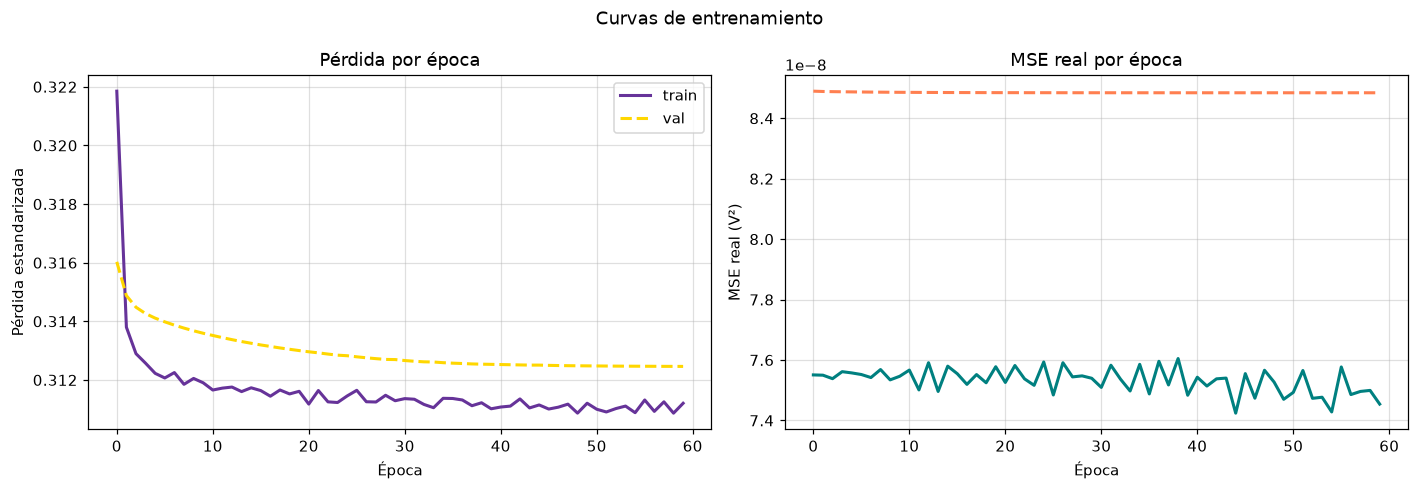

In [6]:
# Curvas de aprendizaje (pérdida estandarizada y MSE real)
plot_training(run_dir / "history.csv")
plt.show()

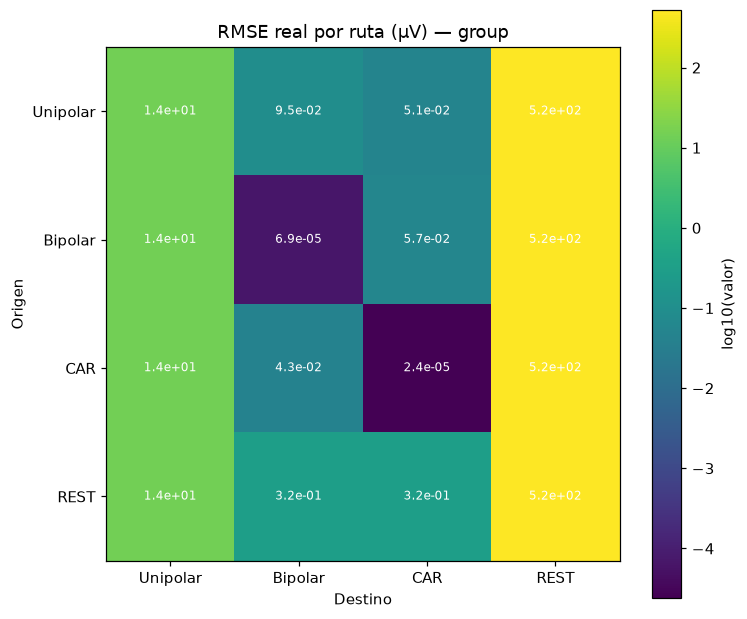

In [7]:
# Heatmap de RMSE real por ruta origen→destino (µV, escala log10)
plot_routes(metrics_df, value_col="rmse",
            title=f"RMSE real por ruta (µV) — {cfg.model.variant}")
plt.show()

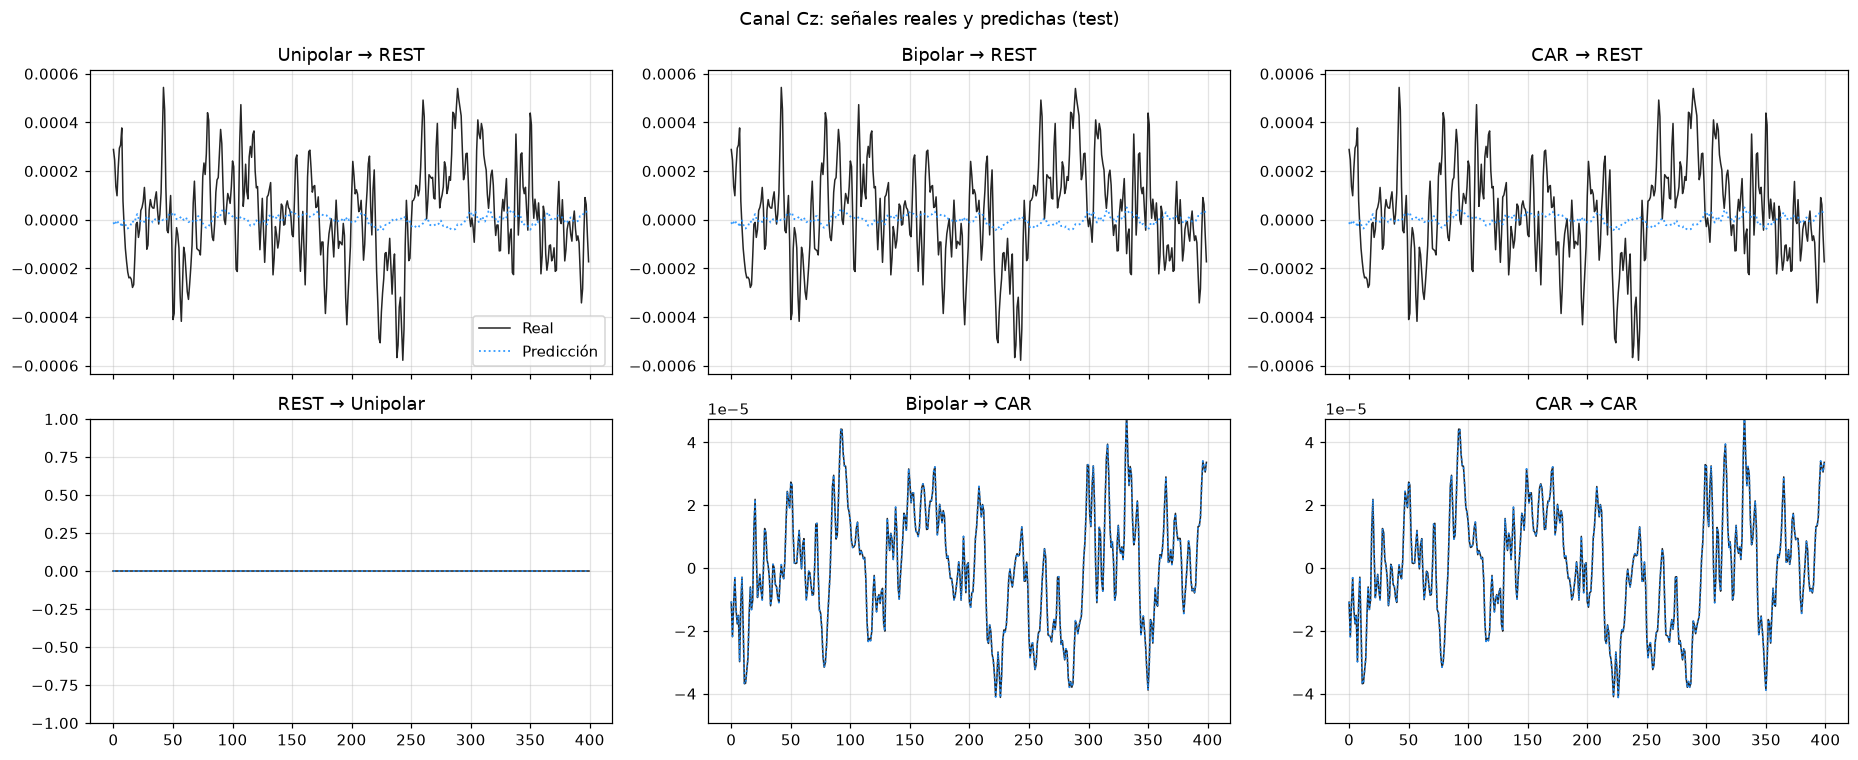

In [8]:
# Trazas reales vs predichas en el canal Cz (test, rutas representativas)
plot_traces(model, ds, cfg)
plt.show()

## Conclusiones

Consulte `docs/results_comparison.md` para la interpretación comparativa completa de todas las variantes. Para esta variante, los resultados esperados se detallan en la introducción.